In [1]:
import sys

sys.path.append("..")

import glob
import os

import pandas as pd

from nnspike.constants import ROI_CNN
from nnspike.data import (
    augment_dataset,
    create_label_dataframe,
    set_spike_status,
    sort_by_frames_number,
)
from notebooks.utils import extract_frames_from_avi_files, get_all_avi_files

course = "right"  # "right" or "left"

ImportError: cannot import name 'ROI_CNN' from 'nnspike.constants' (D:\github\nnspike\notebooks\..\nnspike\constants.py)

## Extract Frames

In [ ]:
# Get all AVI files with their timestamps
avi_files_with_timestamps = get_all_avi_files(
    directory_path="../storage/videos/", filter_timestamp="20250824*"
)
avi_files_with_timestamps

In [ ]:
# Extract frames from all AVI files
if avi_files_with_timestamps:
    print("\nStarting frame extraction...")
    output_dirs_with_timestamps = extract_frames_from_avi_files(
        avi_files_with_timestamps, base_output_dir="../storage/frames/"
    )
    print("\nFrame extraction completed!")
    print(
        f"Successfully created {len(output_dirs_with_timestamps)} output directories:"
    )
    for output_dir, timestamp in output_dirs_with_timestamps:
        print(f"  - {output_dir} (timestamp: {timestamp})")
else:
    print("No AVI files found to process.")
    output_dirs_with_timestamps = []

output_dirs_with_timestamps

In [ ]:
for output_dir, timestamp in output_dirs_with_timestamps:
    print(f"Output directory: {output_dir} (timestamp: {timestamp})")

    label_df = create_label_dataframe(output_dir + "/*", course)
    label_df = sort_by_frames_number(label_df)

    status_df = pd.read_csv(f"../storage/sensor_data/{timestamp}_sensor_log.csv")
    df = set_spike_status(label_df, status_df)

    # Export to a csv file
    df.to_csv(f"../storage/labels/{timestamp}_label.csv", index=False)

## Data Augmentation

In [ ]:
# Define the directory path
directory_path = "../storage/labels"  # Replace with your actual directory path

# Pattern to match all files in the directory
# '*' matches any file or directory name
all_files_pattern = os.path.join(directory_path, "*")

# Get a list of all files and directories
all_entries = glob.glob(all_files_pattern)

# Filter out directories to show only files
raw_csv_labels = [entry for entry in all_entries if os.path.isfile(entry)]
raw_csv_labels

In [ ]:
raw_csv_labels = [
    "../storage/labels\\20250705150757_label.csv",
    "../storage/labels\\20250705153842_label.csv",
]

AUG_FLAG = "aug1"
csv_labels = [path.replace("\\", "/") for path in raw_csv_labels]

for csv_label in csv_labels:
    df = pd.read_csv(csv_label)
    df = df[(df["use"] == True)]
    timestamp = csv_label.split("/")[-1][:14]
    df = augment_dataset(df, 0.5, f"../storage/frames/{timestamp}_{AUG_FLAG}")
    df.to_csv(f"../storage/labels/{timestamp}_{AUG_FLAG}_label.csv", index=False)

## Train on AWS SageMaker 

### Download file from s3

In [2]:
!uv pip install boto3

Using Python 3.12.3 environment at: /home/ubuntu/github/nnspike/.venv
Resolved 7 packages in 85ms                                          
Prepared 4 packages in 281ms                                             
Installed 4 packages in 56ms                                
 + boto3==1.40.48
 + botocore==1.40.48
 + jmespath==1.0.1
 + s3transfer==0.14.0


In [ ]:
import boto3

# Create an S3 client
s3_client = boto3.client(
    "s3",
    aws_access_key_id="aws_key_id",
    aws_secret_access_key="aws_secret_access_key",
)

# Define your S3 bucket name, object key, and local file path
bucket_name = "6m746606-s3-bucket"
s3_object_key = "etrobocon/storage.zip"
local_file_path = "./storage.zip"

try:
    s3_client.download_file(bucket_name, s3_object_key, local_file_path)
    print(f"File '{s3_object_key}' downloaded successfully to '{local_file_path}'")
except Exception as e:
    print(f"Error downloading file: {e}")

File 'etrobocon/storage.zip' downloaded successfully to './storage.zip'


### Extract zip

In [4]:
from zipfile import ZipFile

# Specify the name of your zip file
zip_file_name = "./storage.zip"

try:
    # Open the zip file in read mode ('r')
    with ZipFile(local_file_path, "r") as zip_ref:
        # Extract all contents to the current working directory
        zip_ref.extractall("./temp/")
    print(f"Successfully extracted '{zip_file_name}' to the current directory.")
except FileNotFoundError:
    print(f"Error: The file '{zip_file_name}' was not found.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

Successfully extracted './storage.zip' to the current directory.


In [27]:
import random

random.uniform(1.0, 1.5)

1.1552476095231647

## Proof of Concept for Brightness Adjustment Model

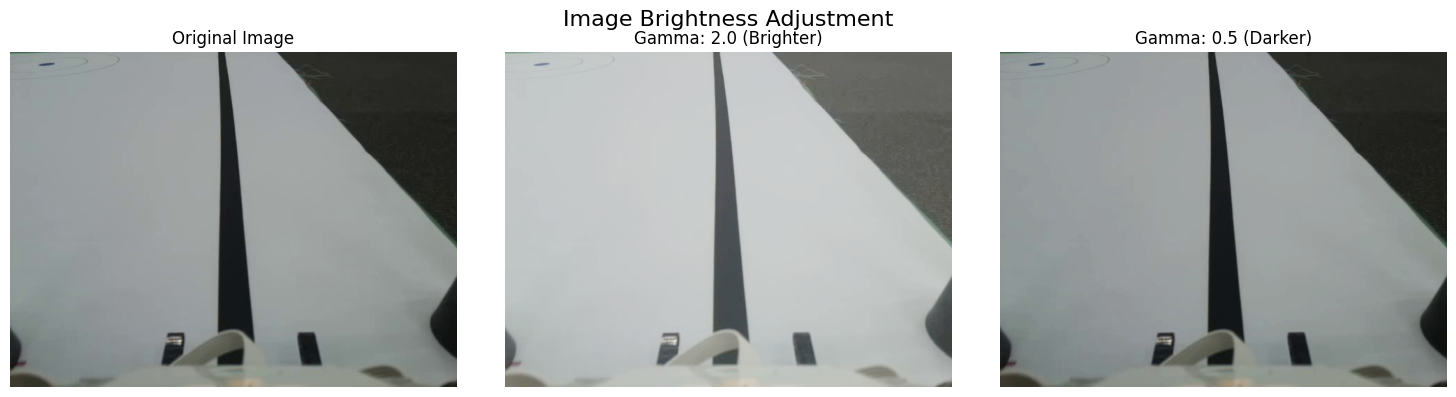

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load an image
image_path = "frame_183.png"  # Using the bottle.jpg from your notebooks folder
image = cv2.imread(image_path)

# Convert BGR to RGB for matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Method 2: Brightness adjustment using multiplication (gamma correction)
def adjust_brightness_gamma(image: np.ndarray, gamma: float) -> np.ndarray:
    """Adjust brightness using gamma correction.

    gamma < 1: darker image
    gamma > 1: brighter image
    """
    # Build a lookup table mapping pixel values [0, 255] to adjusted gamma values
    inv_gamma = 1.0 / gamma
    table = np.array(
        [((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]
    ).astype("uint8")

    # Apply gamma correction using the lookup table
    result: np.ndarray = cv2.LUT(image, table)

    return result


bright_gamma = adjust_brightness_gamma(image_rgb, 2.0)  # Brighter using gamma
dark_gamma = adjust_brightness_gamma(bright_gamma, 1.0 / 2.0)  # Darker using gamma


# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Image Brightness Adjustment", fontsize=16)

# Original image
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Gamma correction
axes[1].imshow(bright_gamma)
axes[1].set_title("Gamma: 2.0 (Brighter)")
axes[1].axis("off")

axes[2].imshow(dark_gamma)
axes[2].set_title("Gamma: 0.5 (Darker)")
axes[2].axis("off")

plt.tight_layout()
plt.show()